In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import numpy as np
import statsmodels.api as sm
from data_preprocessor import preprocessor
from statistics import t_test, t_test_binary_col, anova

In [2]:
font_path = "C:/Windows/Fonts/msjh.ttc"
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 微軟正黑體
plt.rcParams['axes.unicode_minus'] = False  # 正負號也要支援中文

## Data Preprocessing

In [3]:
df = pd.read_csv('LDA topics.csv')
a = preprocessor(df)
data, skill_cols, skill_set_cols, industry_cols = a.col_preprocess()

In [4]:
skill_set_cols

['skill_set_ml_ai', 'skill_set_data_engineer', 'skill_set_llm_image']

In [5]:
salary_data = data[(data['max_salary'] > 0)&(data['max_salary'] < 500000)&(data['salaryType'] != 'H')&(data['salaryType'] != 'D')].copy()
analyst_data = salary_data[(salary_data['topic_job_category']=='BA')|((salary_data['topic_job_category']=='DA')|((salary_data['topic_job_category']=='DS')))].copy()
print(len(salary_data), len(analyst_data))

349 157


## 1. 薪資分析
### 1.1 技能 v.s. 薪資

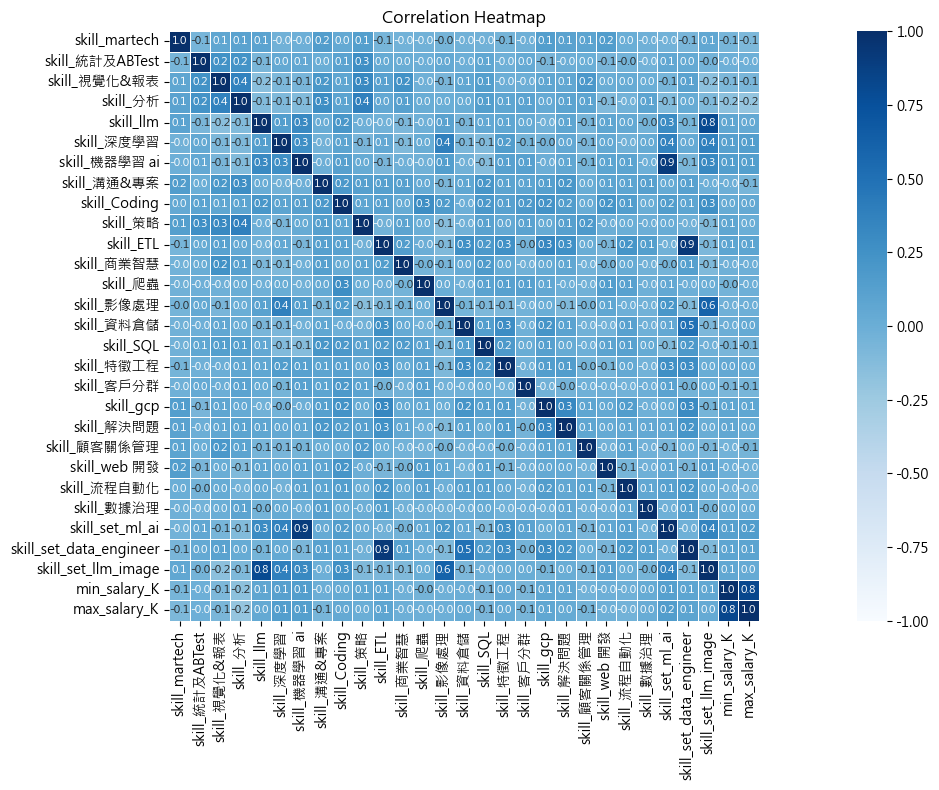

In [6]:
plt.figure(figsize=(20, 8))
sns.heatmap(
    salary_data[skill_cols +skill_set_cols + ['min_salary_K', 'max_salary_K']].corr(),
    annot=True,         # 顯示數字
    fmt=".1f",          # 顯示兩位小數
    cmap='Blues',    # 顏色範圍從藍到紅
    vmin=-1, vmax=1,    # 標準化顏色區間
    linewidths=0.5,
    square=True,
    annot_kws={"size": 8}
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

#### 有沒有各技能對薪資的影響

In [7]:
test_df = t_test_binary_col(salary_data, skill_cols+skill_set_cols, 'min_salary_K', 0.1)
test_df

,name,mean min_salary_K_with,mean min_salary_K_not_with,mean_diff,p_value
3,skill_分析,46.628128,54.408271,-7.780144,0.002751
6,skill_機器學習 ai,52.723615,46.275758,6.447857,0.006931
0,skill_martech,41.760000,49.984769,-8.224769,0.008332
21,skill_set_ml_ai,52.228348,46.177601,6.050746,0.010488
2,skill_視覺化&報表,45.803573,50.884716,-5.081143,0.026595
5,skill_深度學習,55.940047,48.540596,7.399451,0.046525
12,skill_爬蟲,44.545273,49.918458,-5.373185,0.099444


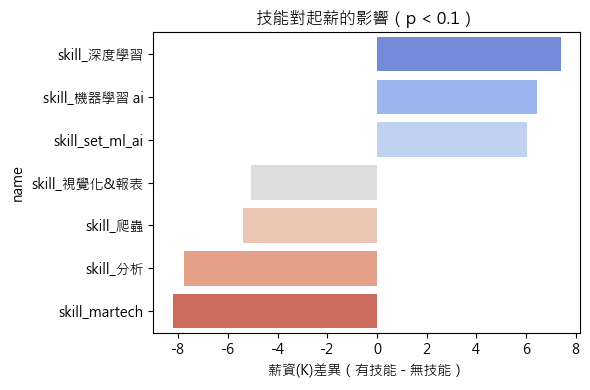

In [8]:
top_skills = test_df.sort_values('mean_diff', ascending=False).head(10)

plt.figure(figsize=(6, 4))
sns.barplot(data=top_skills, x='mean_diff', y='name', palette='coolwarm')
plt.title('技能對起薪的影響（p < 0.1）')
plt.xlabel('薪資(K)差異（有技能 - 無技能）')
plt.tight_layout()
plt.show()

In [9]:
test_df = t_test_binary_col(salary_data, skill_cols+skill_set_cols, 'max_salary_K', 0.1)
test_df

,name,mean max_salary_K_with,mean max_salary_K_not_with,mean_diff,p_value
0,skill_martech,54.860000,80.311806,-25.451806,0.000008
3,skill_分析,71.746783,91.280176,-19.533393,0.000352
21,skill_set_ml_ai,85.425019,71.166072,14.258947,0.001978
6,skill_機器學習 ai,85.522450,72.646470,12.875980,0.006887
5,skill_深度學習,94.511170,76.668376,17.842794,0.043316
22,skill_set_data_engineer,90.368650,78.146713,12.221937,0.048050
10,skill_ETL,90.299074,78.349954,11.949120,0.068693
2,skill_視覺化&報表,72.974521,81.484464,-8.509942,0.084110


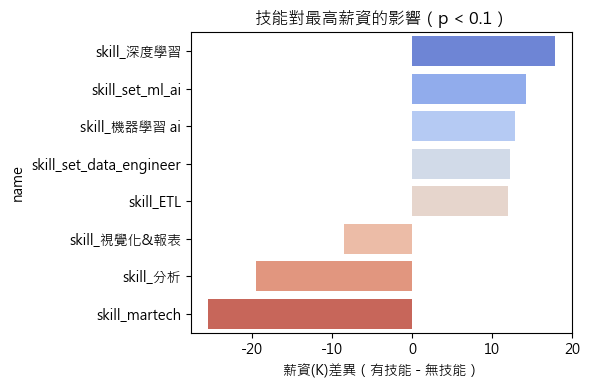

In [10]:
top_skills = test_df.sort_values('mean_diff', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=top_skills, x='mean_diff', y='name', palette='coolwarm')
plt.title('技能對最高薪資的影響（p < 0.1）')
plt.xlabel('薪資(K)差異（有技能 - 無技能）')
plt.tight_layout()
plt.show()

### 1.2 BA/DA/DS 技能樹增值空間

In [11]:
test_df = t_test_binary_col(analyst_data, skill_cols+skill_set_cols, 'max_salary_K', 0.1)
test_df

,name,mean max_salary_K_with,mean max_salary_K_not_with,mean_diff,p_value
4,skill_機器學習 ai,85.957032,69.187000,16.770032,0.022083
12,skill_set_llm_image,116.151515,72.770098,43.381417,0.026314
11,skill_set_data_engineer,107.083333,73.682093,33.401240,0.027401
6,skill_Coding,93.557692,72.287031,21.270662,0.034793
2,skill_分析,70.751963,90.118862,-19.366899,0.039481
10,skill_set_ml_ai,83.553961,69.892491,13.661470,0.049564
3,skill_深度學習,102.911111,72.946721,29.964390,0.053813


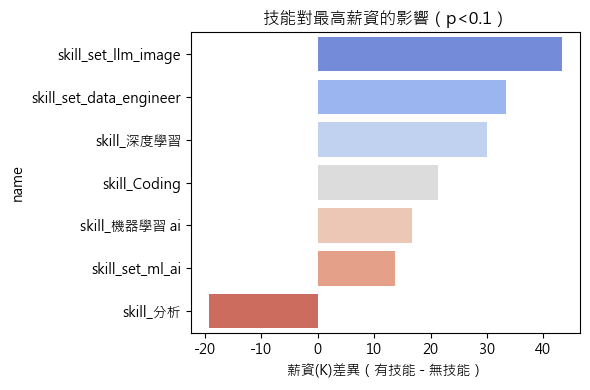

In [12]:
top_skills = test_df.sort_values('mean_diff', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=top_skills, x='mean_diff', y='name', palette='coolwarm')
plt.title('技能對最高薪資的影響（p<0.1）')
plt.xlabel('薪資(K)差異（有技能 - 無技能）')
plt.tight_layout()
plt.show()

In [13]:
test_df = t_test_binary_col(analyst_data, skill_cols+skill_set_cols, 'min_salary_K', 0.1)
test_df

,name,mean min_salary_K_with,mean min_salary_K_not_with,mean_diff,p_value
4,skill_機器學習 ai,56.227183,45.118740,11.108442,0.005022
10,skill_set_ml_ai,54.383608,45.778431,8.605177,0.022023
2,skill_分析,46.479101,58.068049,-11.588948,0.022078
12,skill_set_llm_image,69.106061,48.028760,21.077300,0.030170
11,skill_set_data_engineer,69.750000,48.128338,21.621662,0.036307
3,skill_深度學習,63.477778,48.029570,15.448207,0.054010
6,skill_Coding,57.326923,47.953173,9.373750,0.074426
9,skill_解決問題,59.306772,48.156065,11.150707,0.079759


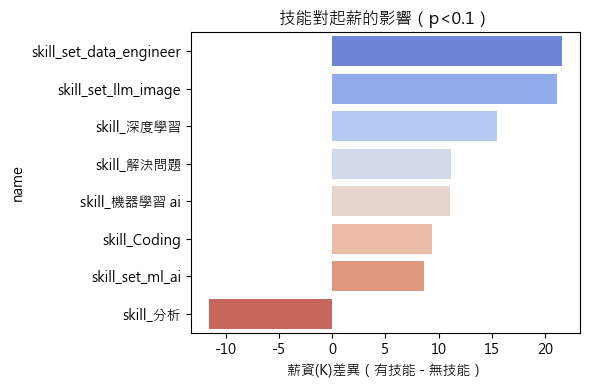

In [14]:
top_skills = test_df.sort_values('mean_diff', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=top_skills, x='mean_diff', y='name', palette='coolwarm')
plt.title('技能對起薪的影響（p<0.1）')
plt.xlabel('薪資(K)差異（有技能 - 無技能）')
plt.tight_layout()
plt.show()

In [15]:
print(skill_cols+skill_set_cols)

['skill_martech', 'skill_統計及ABTest', 'skill_視覺化&報表', 'skill_分析', 'skill_llm', 'skill_深度學習', 'skill_機器學習 ai', 'skill_溝通&專案', 'skill_Coding', 'skill_策略', 'skill_ETL', 'skill_商業智慧', 'skill_爬蟲', 'skill_影像處理', 'skill_資料倉儲', 'skill_SQL', 'skill_特徵工程', 'skill_客戶分群', 'skill_gcp', 'skill_解決問題', 'skill_顧客關係管理', 'skill_web 開發', 'skill_流程自動化', 'skill_數據治理', 'skill_set_ml_ai', 'skill_set_data_engineer', 'skill_set_llm_image']


In [16]:
sig_skills = [
    'skill_martech', 'skill_統計及ABTest', 'skill_視覺化&報表', 
    'skill_分析', 'skill_溝通&專案', 'skill_Coding', 'skill_策略', 
    'skill_商業智慧', 'skill_爬蟲',
    'skill_SQL','skill_客戶分群', 'skill_gcp', 'skill_解決問題', 
    'skill_顧客關係管理', 'skill_web 開發', 'skill_流程自動化', 
    'skill_set_ml_ai', 'skill_set_data_engineer', 'skill_set_llm_image'
]

In [17]:
X = analyst_data[sig_skills]
X = sm.add_constant(X)
y = analyst_data['log_max_salary']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         log_max_salary   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     2.113
Date:                Wed, 16 Apr 2025   Prob (F-statistic):            0.00722
Time:                        12:30:39   Log-Likelihood:                -71.759
No. Observations:                 157   AIC:                             183.5
Df Residuals:                     137   BIC:                             244.6
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

Text(0.5, 1.0, '技能對最高薪資的影響（OLS 係數）')

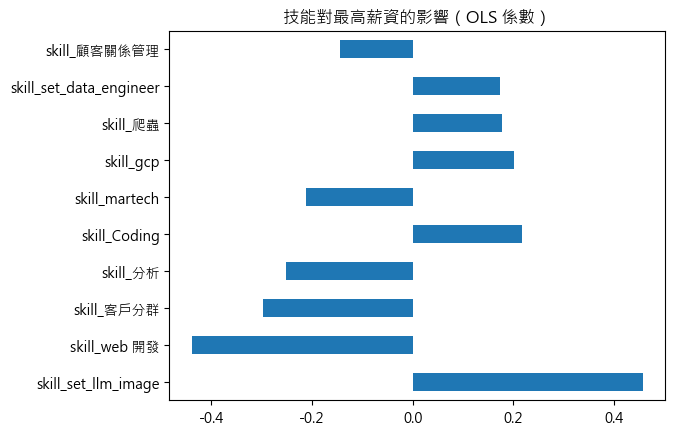

In [18]:
coefs = model.params.drop('const')
coefs[coefs.abs().sort_values(ascending=False).index].head(10).plot(kind='barh')
plt.title("技能對最高薪資的影響（OLS 係數）")

In [19]:
X = analyst_data[sig_skills]
X = sm.add_constant(X)
y = analyst_data['log_min_salary']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         log_min_salary   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     2.216
Date:                Wed, 16 Apr 2025   Prob (F-statistic):            0.00453
Time:                        12:30:51   Log-Likelihood:                -37.884
No. Observations:                 157   AIC:                             115.8
Df Residuals:                     137   BIC:                             176.9
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

Text(0.5, 1.0, '技能對起薪的影響（OLS 係數）')

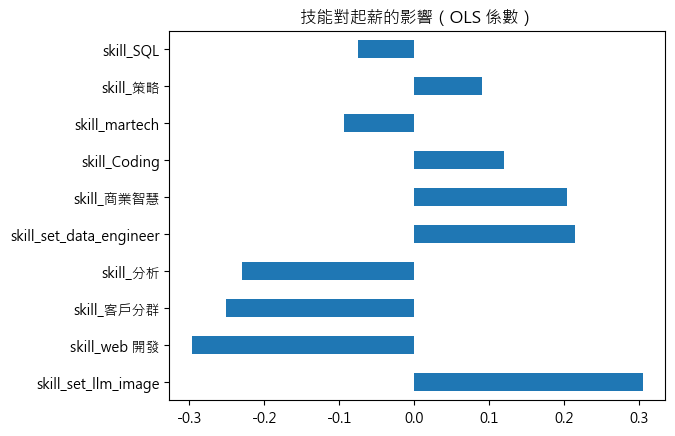

In [20]:
coefs = model.params.drop('const')
coefs[coefs.abs().sort_values(ascending=False).index].head(10).plot(kind='barh')
plt.title("技能對起薪的影響（OLS 係數）")

## 2 .Association Rule 找出技能組合 → 高薪規則推薦

In [25]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [72]:
def association_rule(df, x, y, threshold):
    temp = df.copy()
    # 定義高薪類型
    limit = temp[y].quantile(threshold)
    print(f'top threshold:{limit}')
    col_name = f'top_{y}'
    temp[col_name] = temp[y].apply(lambda x: 1 if x>=limit else 0)
    temp = temp[x+[col_name]].copy()
    
    # 將每一筆轉為一組 "技能名稱" 列表（True 的技能 + 高薪標籤）
    transactions = temp.apply(lambda row: [col for col in temp.columns if row[col] == 1], axis=1)
    te = TransactionEncoder()
    te_array = te.fit(transactions).transform(transactions)
    df_te = pd.DataFrame(te_array, columns=te.columns_)
    
    frequent_itemsets = apriori(df_te, min_support=0.05, use_colnames=True) # 技能要出現在至少 5% 的職缺中
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3) # 高薪職缺的機率可能只有 30%
    # rules_high_salary = rules[rules['consequents'].apply(lambda x: 'is_top_salary' in x)]
    rules_target = rules[rules['consequents'] == frozenset({col_name})]
    rules_target = rules_target[rules_target['lift'] >= 1.5] #穩定性篩選（排除隨機巧合）
    
    rules_target = rules_target.sort_values(by='lift', ascending=False)
    rules_target['antecedents_str'] = rules_target['antecedents'].apply(
        lambda x: ', '.join([i.replace('skill_', '') for i in list(x)])
    )
    
    return rules_target

In [73]:
analyst_data[['max_salary_K', 'log_max_salary', 'min_salary_K', 'log_min_salary']].describe()

,max_salary_K,log_max_salary,min_salary_K,log_min_salary
count,157.000000,157.000000,157.000000,157.000000
mean,75.809561,11.129337,49.505514,10.738443
std,40.846884,0.435983,22.005360,0.353298
min,28.590000,10.260847,28.590000,10.260847
25%,50.000000,10.819798,35.000000,10.463132
50%,60.000000,11.002117,40.000000,10.596660
75%,85.000000,11.350418,53.000000,10.878066
max,250.000000,12.429220,141.666667,11.861239


In [74]:
temp_df = association_rule(analyst_data, skill_cols, 'max_salary_K', 0.7)
temp_df

top threshold:80.0


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedents_str
292,"(skill_深度學習, skill_機器學習 ai)",(top_max_salary_K),0.076433,0.318471,0.050955,0.666667,2.093333,1.0,0.026614,2.044586,0.565517,0.148148,0.510903,0.413333,"深度學習, 機器學習 ai"
525,"(skill_策略, skill_Coding, skill_機器學習 ai)",(top_max_salary_K),0.089172,0.318471,0.057325,0.642857,2.018571,1.0,0.028926,1.908280,0.554002,0.163636,0.475968,0.411429,"策略, Coding, 機器學習 ai"
145,"(skill_Coding, skill_機器學習 ai)",(top_max_salary_K),0.114650,0.318471,0.070064,0.611111,1.918889,1.0,0.033551,1.752502,0.540876,0.192982,0.429387,0.415556,"Coding, 機器學習 ai"
175,"(skill_策略, skill_Coding)",(top_max_salary_K),0.095541,0.318471,0.057325,0.600000,1.884000,1.0,0.026898,1.703822,0.518779,0.160714,0.413084,0.390000,"策略, Coding"
408,"(skill_分析, skill_Coding, skill_機器學習 ai)",(top_max_salary_K),0.095541,0.318471,0.057325,0.600000,1.884000,1.0,0.026898,1.703822,0.518779,0.160714,0.413084,0.390000,"分析, Coding, 機器學習 ai"
515,"(skill_溝通&專案, skill_Coding, skill_機器學習 ai)",(top_max_salary_K),0.101911,0.318471,0.057325,0.562500,1.766250,1.0,0.024869,1.557780,0.483058,0.157895,0.358061,0.371250,"溝通&專案, Coding, 機器學習 ai"
55,(skill_深度學習),(top_max_salary_K),0.095541,0.318471,0.050955,0.533333,1.674667,1.0,0.020528,1.460419,0.445423,0.140351,0.315265,0.346667,深度學習
337,"(skill_統計及ABTest, skill_機器學習 ai)",(top_max_salary_K),0.095541,0.318471,0.050955,0.533333,1.674667,1.0,0.020528,1.460419,0.445423,0.140351,0.315265,0.346667,"統計及ABTest, 機器學習 ai"
640,"(skill_分析, skill_統計及ABTest, skill_機器學習 ai)",(top_max_salary_K),0.095541,0.318471,0.050955,0.533333,1.674667,1.0,0.020528,1.460419,0.445423,0.140351,0.315265,0.346667,"分析, 統計及ABTest, 機器學習 ai"
16,(skill_Coding),(top_max_salary_K),0.165605,0.318471,0.082803,0.500000,1.570000,1.0,0.030062,1.363057,0.435115,0.206349,0.266355,0.380000,Coding


Text(0.5, 1.0, '技能組合與高薪職缺的關聯強度（Lift）')

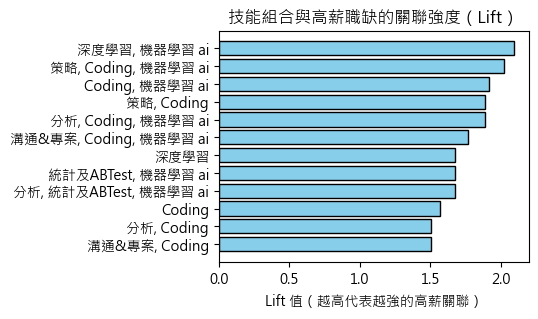

In [75]:
# 畫圖：Lift 條形圖
plt.figure(figsize=(4, 3))
bars = plt.barh(temp_df['antecedents_str'].apply(str), temp_df['lift'], color='skyblue', edgecolor='black')
plt.xlabel('Lift 值（越高代表越強的高薪關聯）')
plt.gca().invert_yaxis()
plt.title('技能組合與高薪職缺的關聯強度（Lift）')

In [76]:
temp_df = association_rule(analyst_data, skill_cols, 'min_salary_K', 0.7)
temp_df

top threshold:50.0


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedents_str
542,"(skill_分析, skill_深度學習, skill_機器學習 ai)",(top_min_salary_K),0.063694,0.33758,0.050955,0.800000,2.369811,1.0,0.029454,3.312102,0.617347,0.145455,0.698077,0.475472,"分析, 深度學習, 機器學習 ai"
727,"(skill_溝通&專案, skill_深度學習, skill_機器學習 ai)",(top_min_salary_K),0.063694,0.33758,0.050955,0.800000,2.369811,1.0,0.029454,3.312102,0.617347,0.145455,0.698077,0.475472,"溝通&專案, 深度學習, 機器學習 ai"
290,"(skill_深度學習, skill_機器學習 ai)",(top_min_salary_K),0.076433,0.33758,0.057325,0.750000,2.221698,1.0,0.031523,2.649682,0.595402,0.160714,0.622596,0.459906,"深度學習, 機器學習 ai"
231,"(skill_分析, skill_深度學習)",(top_min_salary_K),0.070064,0.33758,0.050955,0.727273,2.154374,1.0,0.027303,2.428875,0.576199,0.142857,0.588287,0.439108,"分析, 深度學習"
341,"(skill_溝通&專案, skill_深度學習)",(top_min_salary_K),0.076433,0.33758,0.050955,0.666667,1.974843,1.0,0.025153,1.987261,0.534483,0.140351,0.496795,0.408805,"溝通&專案, 深度學習"
379,"(skill_策略, skill_解決問題)",(top_min_salary_K),0.076433,0.33758,0.050955,0.666667,1.974843,1.0,0.025153,1.987261,0.534483,0.140351,0.496795,0.408805,"策略, 解決問題"
777,"(skill_策略, skill_解決問題, skill_機器學習 ai)",(top_min_salary_K),0.076433,0.33758,0.050955,0.666667,1.974843,1.0,0.025153,1.987261,0.534483,0.140351,0.496795,0.408805,"策略, 解決問題, 機器學習 ai"
72,(skill_解決問題),(top_min_salary_K),0.121019,0.33758,0.076433,0.631579,1.870904,1.0,0.035580,1.797998,0.529589,0.200000,0.443826,0.428997,解決問題
339,"(skill_解決問題, skill_機器學習 ai)",(top_min_salary_K),0.082803,0.33758,0.050955,0.615385,1.822932,1.0,0.023003,1.722293,0.492188,0.137931,0.419379,0.383164,"解決問題, 機器學習 ai"
703,"(skill_溝通&專案, skill_解決問題, skill_分析)",(top_min_salary_K),0.082803,0.33758,0.050955,0.615385,1.822932,1.0,0.023003,1.722293,0.492188,0.137931,0.419379,0.383164,"溝通&專案, 解決問題, 分析"


Text(0.5, 1.0, '技能組合與高起薪職缺的關聯強度（Lift）')

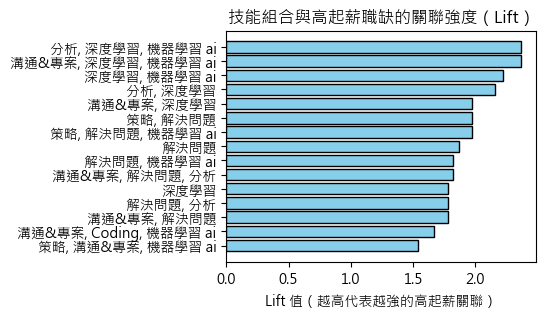

In [77]:
# 畫圖：Lift 條形圖
plt.figure(figsize=(4, 3))
bars = plt.barh(temp_df['antecedents_str'].apply(str), temp_df['lift'], color='skyblue', edgecolor='black')
plt.xlabel('Lift 值（越高代表越強的高起薪關聯）')
plt.gca().invert_yaxis()
plt.title('技能組合與高起薪職缺的關聯強度（Lift）')